
# Lexical Features — Extraction & Quality Check

This notebook:
1. Runs the window-level lexical feature extraction
2. Validates feature distributions and sanity checks
3. Visualizes feature correlations and coverage

**Feature Tiers:**
- **Existing (14):** word_count, unique_words, TTR, agreement, hedging, certainty, positive, negative, question, suggestion, sentiment_ratio, social_composite, bigram/trigram entropy, mean_word_len
- **Tier 1 NEW (12):** discourse markers (5), pronouns (3), participation balance (2), lexical sophistication (1), turn cohesion (1)

In [28]:
import sys
from pathlib import Path

# Add repo root to path
REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'analysis' else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

print(f"Repo root: {REPO_ROOT}")

Repo root: c:\Users\amodica\OneDrive - GN Store Nord\Documents\Codes\affectai-data-processing


## 1. Run Lexical Feature Extraction

Execute the updated extraction script to generate window-level features.

In [29]:
# Reload the module to pick up changes (added concreteness)
import importlib
import analysis.extract_window_lexical_features as lex_module
importlib.reload(lex_module)
print("Module reloaded")

Module reloaded


In [30]:
# Run the extraction script (use reloaded module)
print("Running lexical feature extraction...")
lex_module.main(verbose=True)

WARNING  NLTK not available — lemmatization disabled
INFO  VADER sentiment analyzer enabled


Running lexical feature extraction...


INFO  Loaded concreteness lexicon: 39954 words
INFO  Concreteness lexicon enabled (39954 words)
INFO  Groups: ['grp-07', 'grp-08', 'grp-09', 'grp-10', 'grp-11', 'grp-12', 'grp-13', 'grp-14', 'grp-15', 'grp-16']
INFO  Tasks: ['T1', 'T2', 'T3']
DEBUG  Loaded transcript_grp-07_T1_2026-06-17 (2).tsv: 97 rows
DEBUG  Loaded transcript_grp-07_T2_2026-06-17.tsv: 299 rows
DEBUG  Loaded transcript_grp-07_T3_2026-06-17.tsv: 263 rows
DEBUG  Loaded transcript_grp-10_T1_2026-06-18.tsv: 125 rows
DEBUG  Loaded transcript_grp-10_T2_2026-06-19.tsv: 241 rows
DEBUG  Loaded transcript_grp-10_T3_2026-06-21.tsv: 217 rows
DEBUG  Loaded transcript_grp-14_T1_2026-06-21.tsv: 153 rows
DEBUG  Loaded transcript_grp-14_T2_2026-06-22 (1).tsv: 321 rows
DEBUG  Loaded transcript_grp-14_T3_2026-06-25.tsv: 214 rows
DEBUG  Loaded transcript_grp-15_T1_2026-06-17 (1).tsv: 271 rows
DEBUG  Loaded transcript_grp-15_T2_2026-06-17.tsv: 219 rows
DEBUG  Loaded transcript_grp-15_T3_2026-06-17.tsv: 211 rows
DEBUG  Loaded transcript_g

## 2. Load Extracted Features

In [31]:
# Load the extracted features
lex_path = REPO_ROOT / "analysis" / "results" / "lexical_window_30s.tsv"
lex_df = pd.read_csv(lex_path, sep="\t")

print(f"Loaded {len(lex_df)} windows from {lex_df['group_id'].nunique()} groups × {lex_df['task_id'].nunique()} tasks")
print(f"\nColumns ({len(lex_df.columns)}):")
print(lex_df.columns.tolist())

Loaded 682 windows from 10 groups × 3 tasks

Columns (40):
['group_id', 'task_id', 'window_index', 'window_start_s', 'n_spk_rows', 'n_speakers', 'lex_agreement_count', 'lex_bigram_entropy', 'lex_certainty_count', 'lex_concreteness_coverage', 'lex_concreteness_mean', 'lex_concreteness_std', 'lex_dm_additive', 'lex_dm_causal', 'lex_dm_contrast', 'lex_dm_elaboration', 'lex_dm_temporal', 'lex_hedging_count', 'lex_i_count', 'lex_long_word_ratio', 'lex_mean_word_len', 'lex_negative_count', 'lex_positive_count', 'lex_question_count', 'lex_sentiment_ratio', 'lex_social_composite', 'lex_suggestion_count', 'lex_trigram_entropy', 'lex_ttr', 'lex_turn_cohesion', 'lex_unique_words', 'lex_vader_compound', 'lex_vader_neg', 'lex_vader_neu', 'lex_vader_pos', 'lex_we_count', 'lex_we_i_ratio', 'lex_word_count', 'lex_word_gini', 'lex_word_hhi']


In [32]:
# Separate metadata and feature columns
meta_cols = ["group_id", "task_id", "window_index", "window_start_s", "n_spk_rows", "n_speakers"]
feat_cols = [c for c in lex_df.columns if c.startswith("lex_")]

print(f"Metadata columns: {len(meta_cols)}")
print(f"Feature columns: {len(feat_cols)}")
print(f"\nFeatures:")
for i, col in enumerate(feat_cols, 1):
    print(f"  {i:2d}. {col}")

Metadata columns: 6
Feature columns: 34

Features:
   1. lex_agreement_count
   2. lex_bigram_entropy
   3. lex_certainty_count
   4. lex_concreteness_coverage
   5. lex_concreteness_mean
   6. lex_concreteness_std
   7. lex_dm_additive
   8. lex_dm_causal
   9. lex_dm_contrast
  10. lex_dm_elaboration
  11. lex_dm_temporal
  12. lex_hedging_count
  13. lex_i_count
  14. lex_long_word_ratio
  15. lex_mean_word_len
  16. lex_negative_count
  17. lex_positive_count
  18. lex_question_count
  19. lex_sentiment_ratio
  20. lex_social_composite
  21. lex_suggestion_count
  22. lex_trigram_entropy
  23. lex_ttr
  24. lex_turn_cohesion
  25. lex_unique_words
  26. lex_vader_compound
  27. lex_vader_neg
  28. lex_vader_neu
  29. lex_vader_pos
  30. lex_we_count
  31. lex_we_i_ratio
  32. lex_word_count
  33. lex_word_gini
  34. lex_word_hhi


## 3. Feature Summary Statistics

In [33]:
# Summary statistics for all features
summary = lex_df[feat_cols].describe().T
summary["missing_%"] = (lex_df[feat_cols].isna().sum() / len(lex_df) * 100).round(1)
summary["zeros_%"] = ((lex_df[feat_cols] == 0).sum() / len(lex_df) * 100).round(1)

print("Feature Summary Statistics:")
summary.round(3)

Feature Summary Statistics:


,count,mean,std,min,25%,50%,75%,max,missing_%,zeros_%
lex_agreement_count,682.0,1.877,2.265,0.000,0.000,1.000,3.000,13.000,0.0,36.7
lex_bigram_entropy,513.0,5.394,1.240,0.000,5.003,5.776,6.155,6.941,24.8,1.0
lex_certainty_count,682.0,0.321,0.664,0.000,0.000,0.000,0.000,4.000,0.0,76.8
lex_concreteness_coverage,513.0,0.893,0.089,0.000,0.867,0.904,0.933,1.000,24.8,0.3
lex_concreteness_mean,511.0,2.409,0.181,1.710,2.290,2.397,2.507,3.308,25.1,0.0
lex_concreteness_std,511.0,0.899,0.157,0.000,0.835,0.902,0.986,1.425,25.1,0.6
lex_dm_additive,682.0,1.650,2.070,0.000,0.000,1.000,3.000,10.000,0.0,46.5
lex_dm_causal,682.0,0.849,1.092,0.000,0.000,0.000,1.000,6.000,0.0,50.3
lex_dm_contrast,682.0,0.538,0.892,0.000,0.000,0.000,1.000,7.000,0.0,65.2
lex_dm_elaboration,682.0,1.085,1.802,0.000,0.000,0.000,1.000,11.000,0.0,57.5


## 4. Quality Checks

### 4.1 Missing Values

In [34]:
# Check for missing values
missing = lex_df[feat_cols].isna().sum()
missing_pct = (missing / len(lex_df) * 100).round(1)

missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_%": missing_pct
}).sort_values("missing_%", ascending=False)

print("Features with missing values:")
missing_report[missing_report["missing_%"] > 0]

Features with missing values:


,missing_count,missing_%
lex_we_i_ratio,216,31.7
lex_turn_cohesion,203,29.8
lex_concreteness_std,171,25.1
lex_concreteness_mean,171,25.1
lex_vader_neu,169,24.8
lex_bigram_entropy,169,24.8
lex_mean_word_len,169,24.8
lex_vader_pos,169,24.8
lex_concreteness_coverage,169,24.8
lex_long_word_ratio,169,24.8


### 4.2 Zero-Inflated Features

In [35]:
# Check for zero-inflated features (>50% zeros may indicate sparse signal)
zero_counts = (lex_df[feat_cols] == 0).sum()
zero_pct = (zero_counts / len(lex_df) * 100).round(1)

zero_report = pd.DataFrame({
    "zero_count": zero_counts,
    "zero_%": zero_pct
}).sort_values("zero_%", ascending=False)

print("Features with high zero rates (>50% zeros):")
zero_report[zero_report["zero_%"] > 50]

Features with high zero rates (>50% zeros):


,zero_count,zero_%
lex_negative_count,630,92.4
lex_suggestion_count,596,87.4
lex_certainty_count,524,76.8
lex_dm_temporal,502,73.6
lex_question_count,452,66.3
lex_dm_contrast,445,65.2
lex_dm_elaboration,392,57.5
lex_we_count,385,56.5
lex_dm_causal,343,50.3


### 4.3 Sanity Checks

In [36]:
# Sanity checks
checks = []

# 1. TTR should be in [0, 1]
ttr_valid = lex_df["lex_ttr"].dropna().between(0, 1).all()
checks.append(("TTR in [0,1]", ttr_valid))

# 2. Gini should be in [0, 1] (or NaN)
gini_valid = lex_df["lex_word_gini"].dropna().between(-0.1, 1.1).all()  # small tolerance
checks.append(("Gini in [0,1]", gini_valid))

# 3. HHI should be in [0.25, 1] for 4 speakers
hhi_valid = lex_df["lex_word_hhi"].dropna().between(0.2, 1.1).all()
checks.append(("HHI in [0.25,1]", hhi_valid))

# 4. We/I ratio should be in [0, 1]
wei_valid = lex_df["lex_we_i_ratio"].dropna().between(0, 1).all()
checks.append(("We/I ratio in [0,1]", wei_valid))

# 5. Long word ratio should be in [0, 1]
lwr_valid = lex_df["lex_long_word_ratio"].dropna().between(0, 1).all()
checks.append(("Long word ratio in [0,1]", lwr_valid))

# 6. Turn cohesion (Jaccard) should be in [0, 1]
coh_valid = lex_df["lex_turn_cohesion"].dropna().between(0, 1).all()
checks.append(("Turn cohesion in [0,1]", coh_valid))

# 7. Counts should be non-negative
count_cols = [c for c in feat_cols if "count" in c]
counts_valid = (lex_df[count_cols] >= 0).all().all()
checks.append(("All counts >= 0", counts_valid))

print("Sanity Checks:")
for name, passed in checks:
    status = "✓ PASS" if passed else "✗ FAIL"
    print(f"  {status}: {name}")

Sanity Checks:
  ✓ PASS: TTR in [0,1]
  ✓ PASS: Gini in [0,1]
  ✓ PASS: HHI in [0.25,1]
  ✓ PASS: We/I ratio in [0,1]
  ✓ PASS: Long word ratio in [0,1]
  ✓ PASS: Turn cohesion in [0,1]
  ✓ PASS: All counts >= 0


## 4.4 VADER Sentiment vs Simple Word-List Comparison

Compare VADER (handles negation, intensifiers) vs our simple word-list approach.

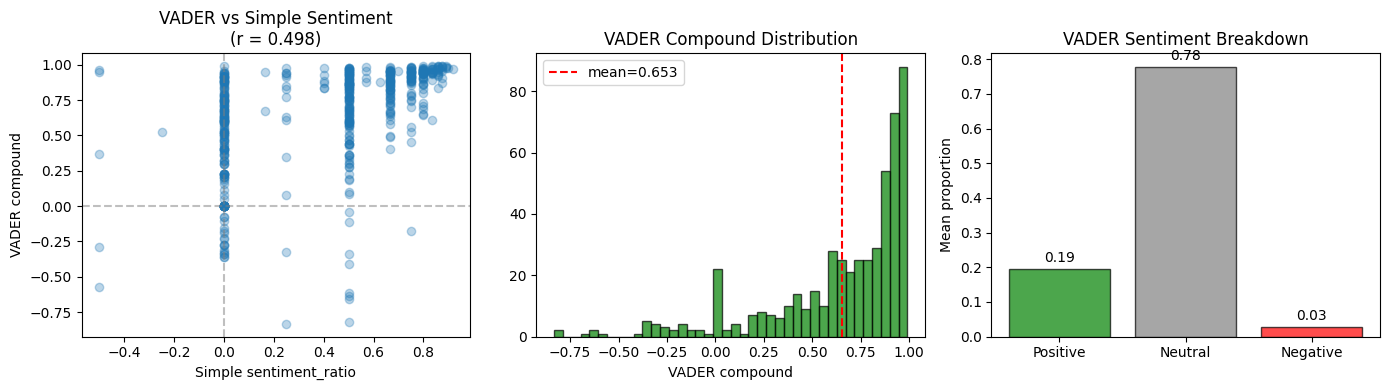


Correlation: VADER compound vs simple sentiment_ratio = 0.498
  → Moderate correlation

VADER summary:
  - Mean compound: 0.653 (range [-0.833, 0.991])
  - Mean positive: 0.194
  - Mean neutral:  0.778
  - Mean negative: 0.027


In [37]:
# Compare VADER compound vs simple sentiment_ratio
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Scatter: VADER compound vs simple sentiment ratio
ax = axes[0]
valid_mask = lex_df["lex_vader_compound"].notna() & lex_df["lex_sentiment_ratio"].notna()
ax.scatter(lex_df.loc[valid_mask, "lex_sentiment_ratio"], 
           lex_df.loc[valid_mask, "lex_vader_compound"], alpha=0.3)
ax.set_xlabel("Simple sentiment_ratio")
ax.set_ylabel("VADER compound")
corr = lex_df.loc[valid_mask, ["lex_sentiment_ratio", "lex_vader_compound"]].corr().iloc[0,1]
ax.set_title(f"VADER vs Simple Sentiment\n(r = {corr:.3f})")
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)

# Distribution: VADER compound
ax = axes[1]
ax.hist(lex_df["lex_vader_compound"].dropna(), bins=40, edgecolor='black', alpha=0.7, color='green')
ax.axvline(lex_df["lex_vader_compound"].mean(), color='red', linestyle='--', label=f"mean={lex_df['lex_vader_compound'].mean():.3f}")
ax.set_xlabel("VADER compound")
ax.set_title("VADER Compound Distribution")
ax.legend()

# Distribution: VADER pos/neg/neu
ax = axes[2]
vader_props = pd.DataFrame({
    "Positive": lex_df["lex_vader_pos"].dropna(),
    "Neutral": lex_df["lex_vader_neu"].dropna(),
    "Negative": lex_df["lex_vader_neg"].dropna()
})
vader_means = vader_props.mean()
ax.bar(vader_means.index, vader_means.values, color=['green', 'gray', 'red'], alpha=0.7, edgecolor='black')
ax.set_ylabel("Mean proportion")
ax.set_title("VADER Sentiment Breakdown")
for i, v in enumerate(vader_means.values):
    ax.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nCorrelation: VADER compound vs simple sentiment_ratio = {corr:.3f}")
print(f"  → {'Strong' if abs(corr) > 0.7 else 'Moderate' if abs(corr) > 0.4 else 'Weak'} correlation")
print(f"\nVADER summary:")
print(f"  - Mean compound: {lex_df['lex_vader_compound'].mean():.3f} (range [{lex_df['lex_vader_compound'].min():.3f}, {lex_df['lex_vader_compound'].max():.3f}])")
print(f"  - Mean positive: {lex_df['lex_vader_pos'].mean():.3f}")
print(f"  - Mean neutral:  {lex_df['lex_vader_neu'].mean():.3f}")
print(f"  - Mean negative: {lex_df['lex_vader_neg'].mean():.3f}")

### 4.5 Concreteness (Brysbaert et al. 2014)

Used by Lai & Murray (2018) — scale: 1 (abstract) to 5 (concrete).

INFO  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


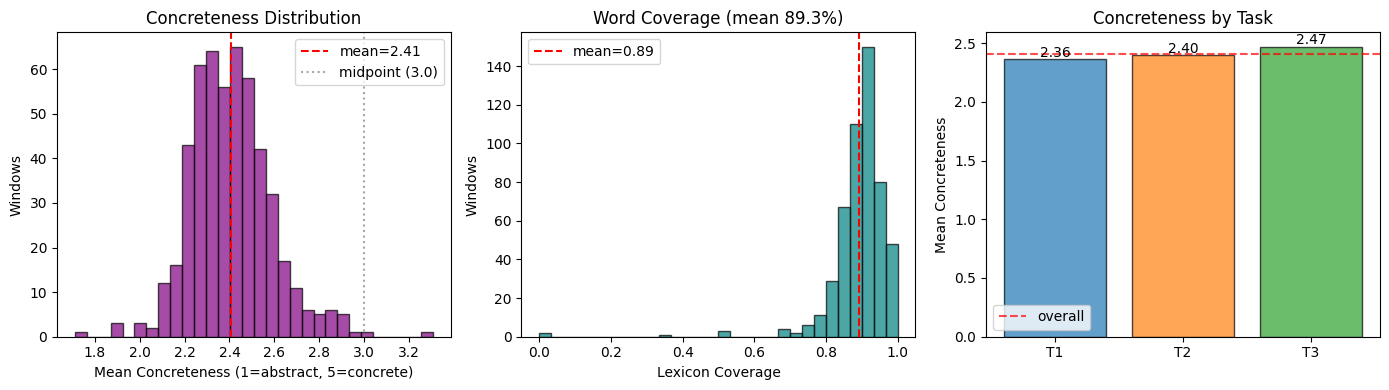


Concreteness Summary:
  - Mean: 2.409 (1=abstract, 5=concrete)
  - Meeting speech is moderately ABSTRACT (below midpoint of 3.0)
  - Lexicon coverage: 89.3% of words matched
  - Reference: Lai & Murray (2018) used this feature from MRC psycholinguistic database


In [38]:
# Concreteness QC
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Distribution of mean concreteness
ax = axes[0]
data = lex_df["lex_concreteness_mean"].dropna()
ax.hist(data, bins=30, edgecolor='black', alpha=0.7, color='purple')
ax.axvline(data.mean(), color='red', linestyle='--', label=f"mean={data.mean():.2f}")
ax.axvline(3.0, color='gray', linestyle=':', alpha=0.7, label="midpoint (3.0)")
ax.set_xlabel("Mean Concreteness (1=abstract, 5=concrete)")
ax.set_ylabel("Windows")
ax.set_title("Concreteness Distribution")
ax.legend()

# Coverage (what % of words found in lexicon)
ax = axes[1]
data = lex_df["lex_concreteness_coverage"].dropna()
ax.hist(data, bins=30, edgecolor='black', alpha=0.7, color='teal')
ax.axvline(data.mean(), color='red', linestyle='--', label=f"mean={data.mean():.2f}")
ax.set_xlabel("Lexicon Coverage")
ax.set_ylabel("Windows")
ax.set_title(f"Word Coverage (mean {data.mean():.1%})")
ax.legend()

# Concreteness by task
ax = axes[2]
task_conc = lex_df.groupby("task_id")["lex_concreteness_mean"].mean()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
bars = ax.bar(task_conc.index, task_conc.values, color=colors, edgecolor='black', alpha=0.7)
ax.set_ylabel("Mean Concreteness")
ax.set_title("Concreteness by Task")
ax.axhline(lex_df["lex_concreteness_mean"].mean(), color='red', linestyle='--', alpha=0.7, label="overall")
for bar, val in zip(bars, task_conc.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.2f}", ha='center', fontsize=10)
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nConcreteness Summary:")
print(f"  - Mean: {lex_df['lex_concreteness_mean'].mean():.3f} (1=abstract, 5=concrete)")
print(f"  - Meeting speech is moderately ABSTRACT (below midpoint of 3.0)")
print(f"  - Lexicon coverage: {lex_df['lex_concreteness_coverage'].mean():.1%} of words matched")
print(f"  - Reference: Lai & Murray (2018) used this feature from MRC psycholinguistic database")

## 5. Feature Distributions

### 5.1 Tier 1 NEW Features

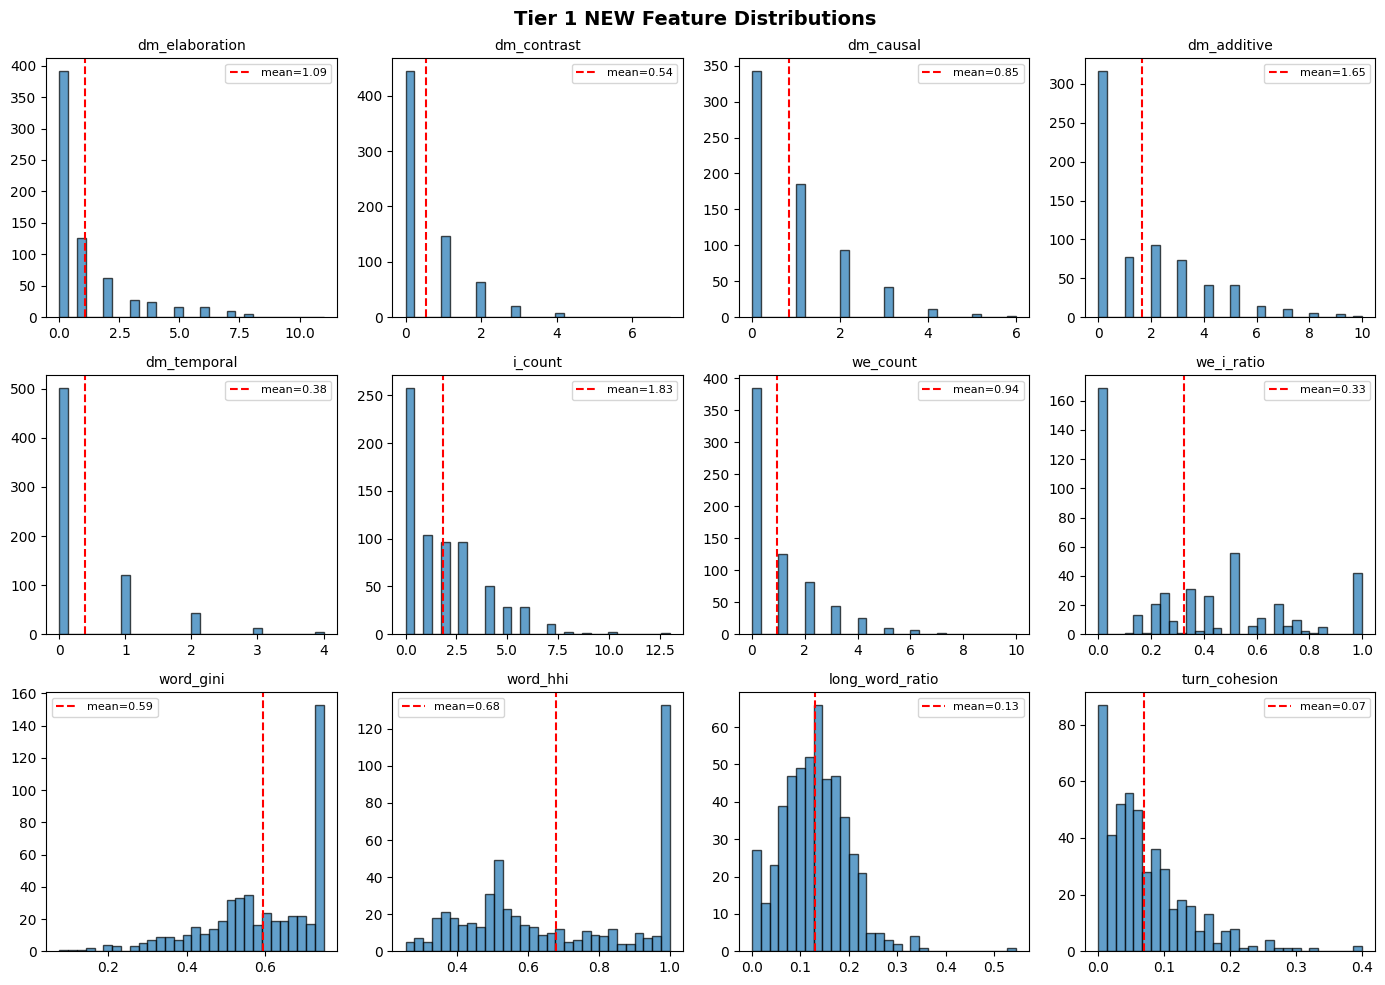

In [39]:
# Plot distributions of TIER 1 NEW features
tier1_features = [
    # Discourse markers
    "lex_dm_elaboration", "lex_dm_contrast", "lex_dm_causal", 
    "lex_dm_additive", "lex_dm_temporal",
    # Pronouns
    "lex_i_count", "lex_we_count", "lex_we_i_ratio",
    # Participation balance
    "lex_word_gini", "lex_word_hhi",
    # Sophistication & cohesion
    "lex_long_word_ratio", "lex_turn_cohesion"
]

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(tier1_features):
    ax = axes[i]
    data = lex_df[col].dropna()
    ax.hist(data, bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'mean={data.mean():.2f}')
    ax.set_title(col.replace('lex_', ''), fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle("Tier 1 NEW Feature Distributions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Existing Features

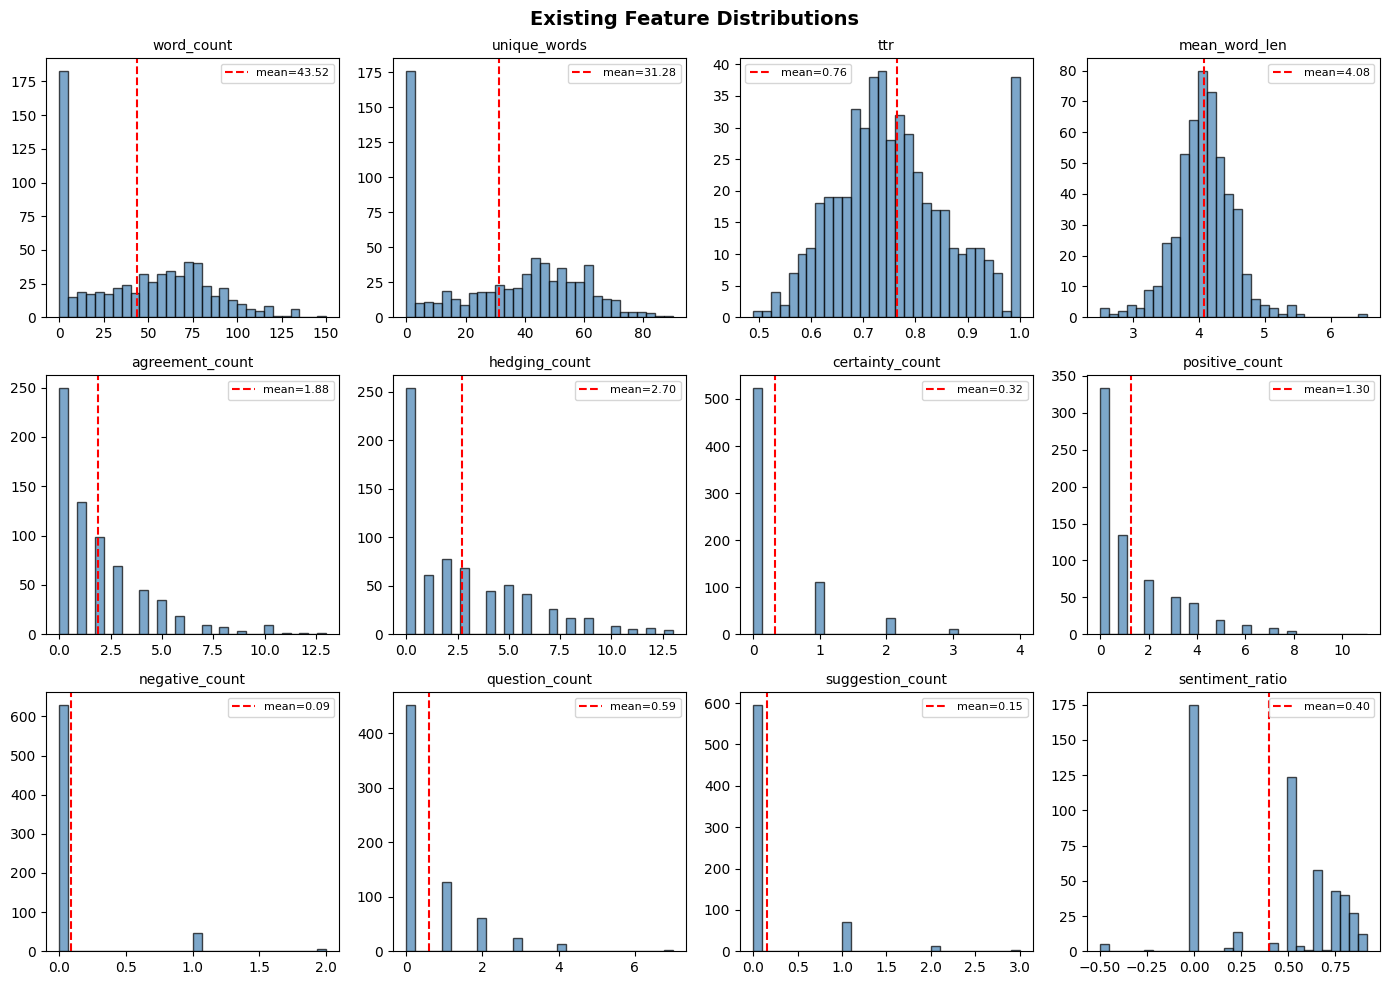

In [40]:
# Plot distributions of existing (original) features
existing_features = [
    "lex_word_count", "lex_unique_words", "lex_ttr", "lex_mean_word_len",
    "lex_agreement_count", "lex_hedging_count", "lex_certainty_count",
    "lex_positive_count", "lex_negative_count", "lex_question_count",
    "lex_suggestion_count", "lex_sentiment_ratio"
]

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(existing_features):
    ax = axes[i]
    data = lex_df[col].dropna()
    ax.hist(data, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'mean={data.mean():.2f}')
    ax.set_title(col.replace('lex_', ''), fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle("Existing Feature Distributions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Feature Correlations

DEBUG  locator: <matplotlib.ticker.AutoLocator object at 0x00000293C9EEA210>


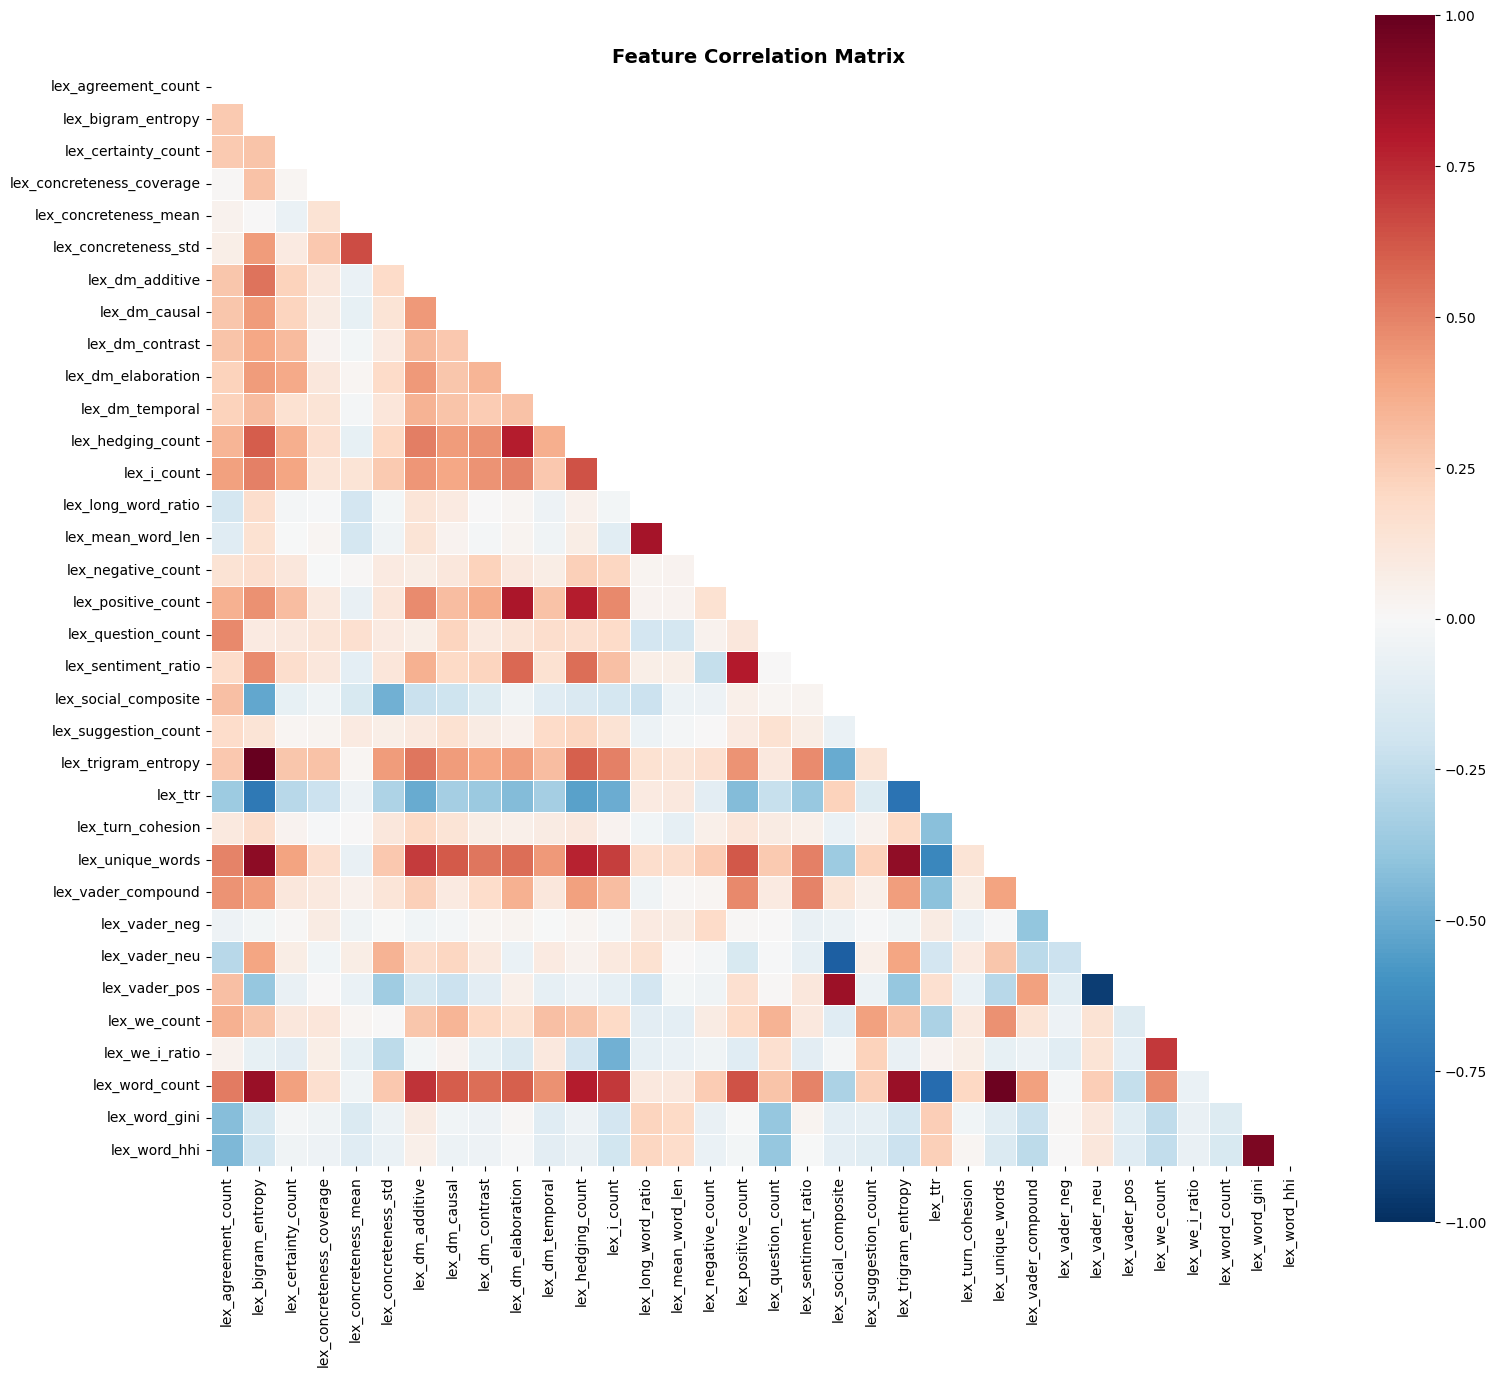

In [41]:
# Correlation matrix for all features
corr_matrix = lex_df[feat_cols].corr()

plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=False, 
    cmap='RdBu_r', 
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)
plt.title("Feature Correlation Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [42]:
# Find highly correlated pairs (|r| > 0.7)
high_corr_pairs = []
for i, col1 in enumerate(feat_cols):
    for col2 in feat_cols[i+1:]:
        r = corr_matrix.loc[col1, col2]
        if abs(r) > 0.7:
            high_corr_pairs.append((col1, col2, r))

if high_corr_pairs:
    print("Highly correlated feature pairs (|r| > 0.7):")
    high_corr_df = pd.DataFrame(high_corr_pairs, columns=["Feature 1", "Feature 2", "Correlation"])
    high_corr_df = high_corr_df.sort_values("Correlation", key=abs, ascending=False)
    display(high_corr_df)
else:
    print("No highly correlated pairs found (|r| > 0.7)")

Highly correlated feature pairs (|r| > 0.7):


,Feature 1,Feature 2,Correlation
0,lex_bigram_entropy,lex_trigram_entropy,0.997013
19,lex_unique_words,lex_word_count,0.982863
20,lex_vader_neu,lex_vader_pos,-0.946094
22,lex_word_gini,lex_word_hhi,0.941308
2,lex_bigram_entropy,lex_unique_words,0.897254
16,lex_trigram_entropy,lex_unique_words,0.888017
3,lex_bigram_entropy,lex_word_count,0.865552
17,lex_trigram_entropy,lex_word_count,0.861762
14,lex_social_composite,lex_vader_pos,0.854296
11,lex_long_word_ratio,lex_mean_word_len,0.832222


## 7. Coverage by Group × Task

In [43]:
# Windows per group × task
coverage = lex_df.groupby(["group_id", "task_id"]).agg({
    "window_index": "count",
    "lex_word_count": "mean",
    "n_speakers": "mean"
}).rename(columns={"window_index": "n_windows"})

coverage_pivot = coverage["n_windows"].unstack(fill_value=0)
print("Windows per Group × Task:")
display(coverage_pivot)

print(f"\nTotal windows: {len(lex_df)}")
print(f"Mean windows per group×task: {coverage_pivot.values.mean():.1f}")

Windows per Group × Task:


task_id,T1,T2,T3
group_id,,,
grp-07,14,31,23
grp-08,29,34,32
grp-09,0,20,25
grp-10,20,30,22
grp-11,19,29,17
grp-12,22,28,24
grp-13,20,24,0
grp-14,22,28,22
grp-15,21,26,24



Total windows: 682
Mean windows per group×task: 22.7


## 8. Task-Level Aggregation Preview

Preview what the task-level features will look like (for the n=27 prediction models).

In [44]:
# Aggregate to task level (mean of windows)
task_agg = lex_df.groupby(["group_id", "task_id"])[feat_cols].mean().reset_index()

print(f"Task-level aggregation: {len(task_agg)} observations (groups × tasks)")
print(f"Expected for HMM prediction: n=27 (9 groups × 3 tasks) or similar")
print(f"\nTask-level summary:")
task_agg[feat_cols].describe().T.round(3)

Task-level aggregation: 28 observations (groups × tasks)
Expected for HMM prediction: n=27 (9 groups × 3 tasks) or similar

Task-level summary:


,count,mean,std,min,25%,50%,75%,max
lex_agreement_count,28.0,1.887,0.753,0.650,1.460,1.661,2.206,4.118
lex_bigram_entropy,28.0,5.424,0.437,4.440,5.217,5.597,5.704,6.003
lex_certainty_count,28.0,0.318,0.158,0.045,0.206,0.293,0.416,0.667
lex_concreteness_coverage,28.0,0.892,0.026,0.812,0.881,0.894,0.910,0.925
lex_concreteness_mean,28.0,2.409,0.071,2.321,2.364,2.392,2.428,2.612
lex_concreteness_std,28.0,0.902,0.056,0.810,0.868,0.888,0.913,1.038
lex_dm_additive,28.0,1.635,0.499,0.483,1.273,1.650,1.957,2.548
lex_dm_causal,28.0,0.839,0.260,0.294,0.654,0.833,0.923,1.464
lex_dm_contrast,28.0,0.527,0.193,0.217,0.396,0.536,0.587,1.036
lex_dm_elaboration,28.0,1.060,0.600,0.241,0.522,0.957,1.565,2.429


## 9. Save QC Report

## 5. Feature Correlation Analysis

With n=27 observations and 34 features, multicollinearity is a major concern.

**Rule of thumb:** Need 10-20 observations per feature → should have 3-5 features max.

This section identifies highly correlated features (|r| > 0.7) that are candidates for removal.

DEBUG  locator: <matplotlib.ticker.AutoLocator object at 0x00000293CD4F00E0>


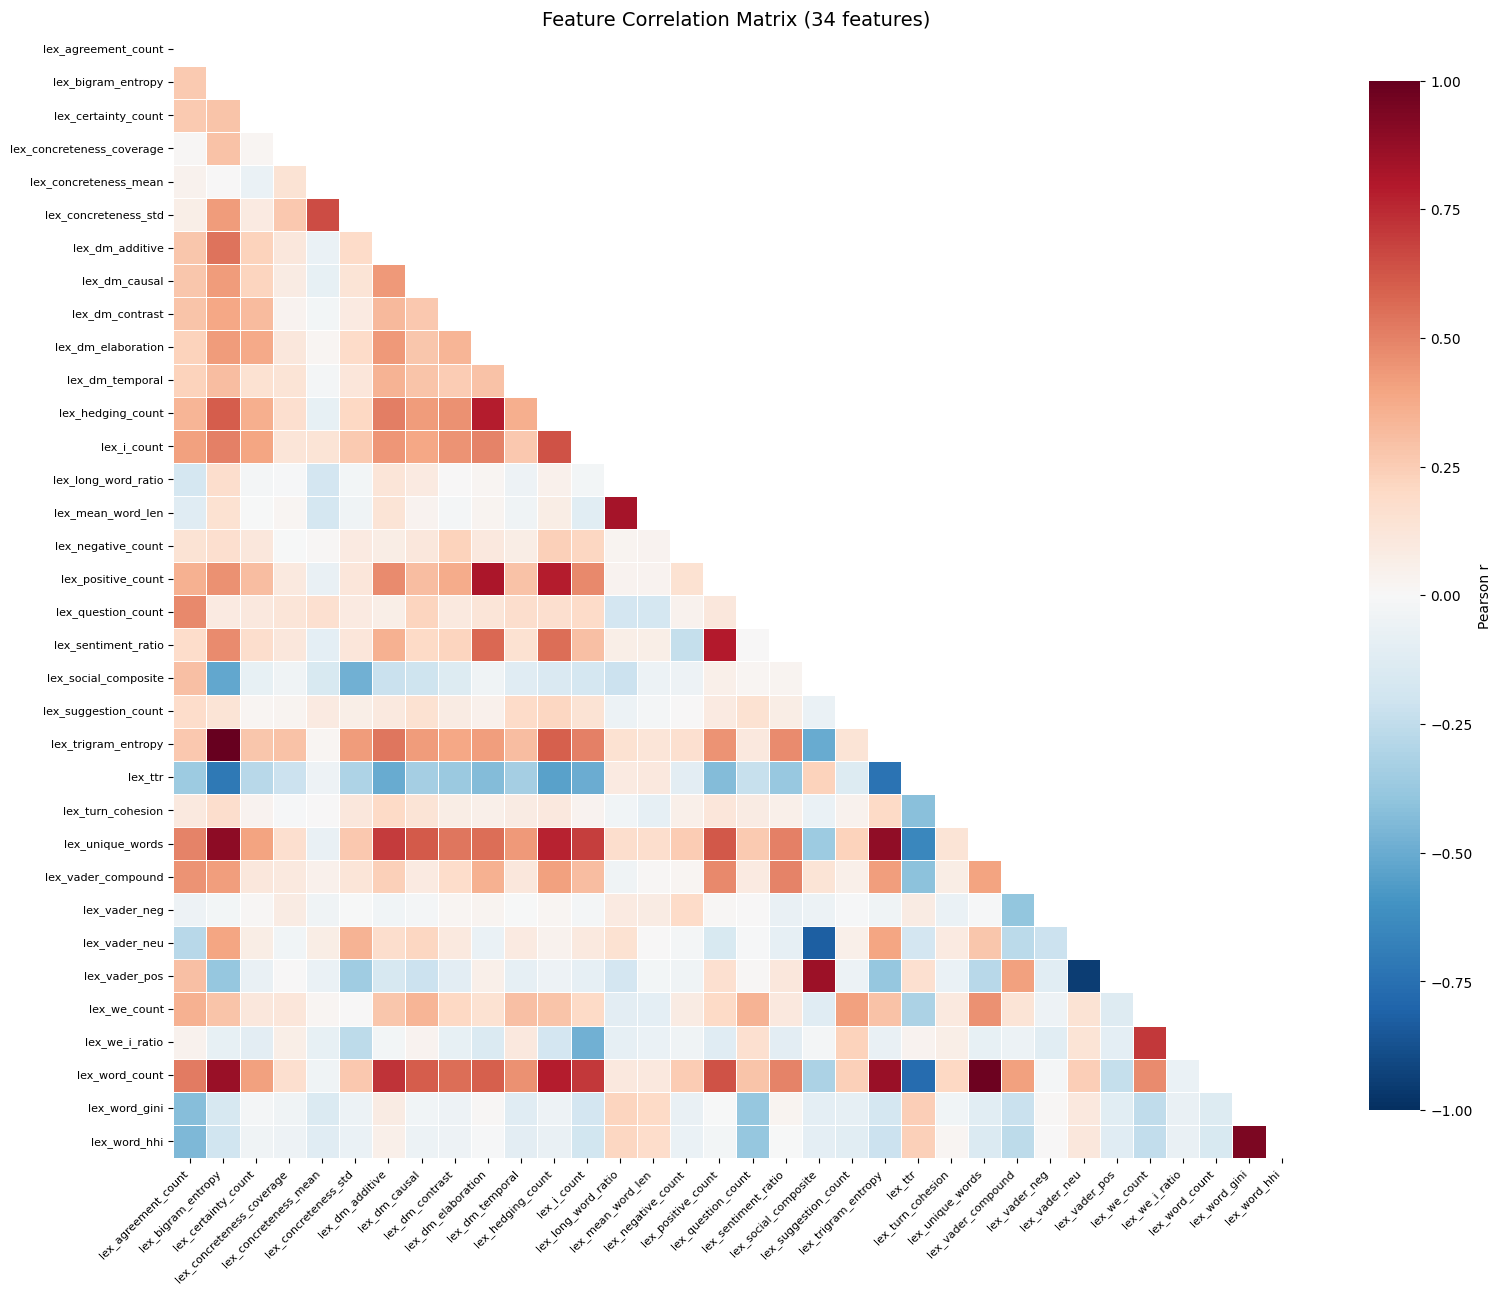

In [45]:
# Correlation heatmap of all features
import seaborn as sns

corr_matrix = lex_df[feat_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8, "label": "Pearson r"})
ax.set_title("Feature Correlation Matrix (34 features)", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [46]:
# Find highly correlated feature pairs (|r| > 0.7)
threshold = 0.7
high_corr_pairs = []

for i, col1 in enumerate(feat_cols):
    for j, col2 in enumerate(feat_cols):
        if i < j:  # upper triangle only
            r = corr_matrix.loc[col1, col2]
            if abs(r) >= threshold:
                high_corr_pairs.append((col1, col2, r))

# Sort by absolute correlation
high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print(f"Highly correlated feature pairs (|r| ≥ {threshold}):")
print("="*70)
for col1, col2, r in high_corr_pairs:
    print(f"  r={r:+.2f}: {col1.replace('lex_', '')} ↔ {col2.replace('lex_', '')}")
print(f"\nTotal: {len(high_corr_pairs)} pairs with |r| ≥ {threshold}")

Highly correlated feature pairs (|r| ≥ 0.7):
  r=+1.00: bigram_entropy ↔ trigram_entropy
  r=+0.98: unique_words ↔ word_count
  r=-0.95: vader_neu ↔ vader_pos
  r=+0.94: word_gini ↔ word_hhi
  r=+0.90: bigram_entropy ↔ unique_words
  r=+0.89: trigram_entropy ↔ unique_words
  r=+0.87: bigram_entropy ↔ word_count
  r=+0.86: trigram_entropy ↔ word_count
  r=+0.85: social_composite ↔ vader_pos
  r=+0.83: long_word_ratio ↔ mean_word_len
  r=-0.82: social_composite ↔ vader_neu
  r=+0.81: dm_elaboration ↔ positive_count
  r=+0.79: positive_count ↔ sentiment_ratio
  r=+0.79: hedging_count ↔ word_count
  r=+0.78: dm_elaboration ↔ hedging_count
  r=+0.78: hedging_count ↔ positive_count
  r=-0.77: ttr ↔ word_count
  r=+0.77: hedging_count ↔ unique_words
  r=-0.74: trigram_entropy ↔ ttr
  r=+0.72: dm_additive ↔ word_count
  r=-0.72: bigram_entropy ↔ ttr
  r=+0.71: we_count ↔ we_i_ratio
  r=+0.71: i_count ↔ word_count

Total: 23 pairs with |r| ≥ 0.7


In [52]:
# Suggest features to DROP based on redundancy
# Logic: When two features correlate |r| > 0.7, keep the more interpretable/established one

drop_candidates = {
    # VADER neutrality is 1 - (pos+neg), so nearly perfectly redundant
    "lex_vader_neu": "redundant with vader_pos (r=-0.95)",
    # HHI and Gini measure the same thing (concentration/balance)
    "lex_word_hhi": "redundant with word_gini (r=0.94); Gini more interpretable",
    # word_count drives many other features
    "lex_word_count": "confounds other features; consider normalizing",
    # unique_words ~ word_count
    "lex_unique_words": "near-perfect r=0.98 with word_count; use TTR instead",
    # trigram = bigram entropy
    "lex_trigram_entropy": "r=1.00 with bigram_entropy",
    # mean_word_len ~ long_word_ratio
    "lex_mean_word_len": "r=0.83 with long_word_ratio; ratio more interpretable",
    # concreteness_std is less interpretable
    "lex_concreteness_std": "mean is sufficient for Lai & Murray comparison",
    # clause_density and parse_depth are correlated
    "lex_clause_density": "correlated with parse_depth; keep subordination_ratio",
}

keep_features = {
    "lex_ttr": "lexical diversity — established metric",
    "lex_vader_compound": "VADER sentiment — handles negation",
    "lex_dm_elaboration": "discourse marker — cognitive complexity",
    "lex_dm_causal": "discourse marker — reasoning quality", 
    "lex_we_i_ratio": "pronoun — group vs individual focus",
    "lex_word_gini": "participation balance — inequality measure",
    "lex_long_word_ratio": "lexical sophistication",
    "lex_concreteness_mean": "psycholinguistic — Lai & Murray (2018)",
    "lex_turn_cohesion": "coherence between turns",
    "lex_subordination_ratio": "syntactic complexity — clause structure (Tier 3)",
}

print("RECOMMENDED FEATURE TRIMMING")
print("="*70)
print("\n❌ DROP (redundant/confounding):")
for feat, reason in drop_candidates.items():
    print(f"   {feat.replace('lex_', '')}: {reason}")

print(f"\n✓ KEEP (10 core features for n=27):")
for feat, reason in keep_features.items():
    print(f"   {feat.replace('lex_', '')}: {reason}")

print(f"\n→ Final set: {len(keep_features)} features")
print(f"→ Rule of thumb: n/p = 27/{len(keep_features)} = {27/len(keep_features):.1f} obs/feature")
print(f"→ May need further reduction or regularization for regression")

RECOMMENDED FEATURE TRIMMING

❌ DROP (redundant/confounding):
   vader_neu: redundant with vader_pos (r=-0.95)
   word_hhi: redundant with word_gini (r=0.94); Gini more interpretable
   word_count: confounds other features; consider normalizing
   unique_words: near-perfect r=0.98 with word_count; use TTR instead
   trigram_entropy: r=1.00 with bigram_entropy
   mean_word_len: r=0.83 with long_word_ratio; ratio more interpretable
   concreteness_std: mean is sufficient for Lai & Murray comparison
   clause_density: correlated with parse_depth; keep subordination_ratio

✓ KEEP (10 core features for n=27):
   ttr: lexical diversity — established metric
   vader_compound: VADER sentiment — handles negation
   dm_elaboration: discourse marker — cognitive complexity
   dm_causal: discourse marker — reasoning quality
   we_i_ratio: pronoun — group vs individual focus
   word_gini: participation balance — inequality measure
   long_word_ratio: lexical sophistication
   concreteness_mean: psyc

### 5.1 Model-Specific Feature Sets

| Model | Features | Rationale |
|-------|----------|-----------|
| **HMM** (682 windows) | All 37 | More observations allow more features |
| **Ridge Regression** (n=27) | 10 trimmed | Correlation + domain-based selection |
| **Ensemble** | All 37 | Tree models handle correlation well |

**Tier 3 Syntactic Complexity** adds 3 features via spaCy dependency parsing:
- `subordination_ratio` — retained in trimmed set (captures clause complexity)
- `parse_depth_mean` / `clause_density` — available for HMM/ensemble only

DEBUG  locator: <matplotlib.ticker.AutoLocator object at 0x00000293CF11E960>


Correlation matrix for TRIMMED feature set (10 features):
------------------------------------------------------------


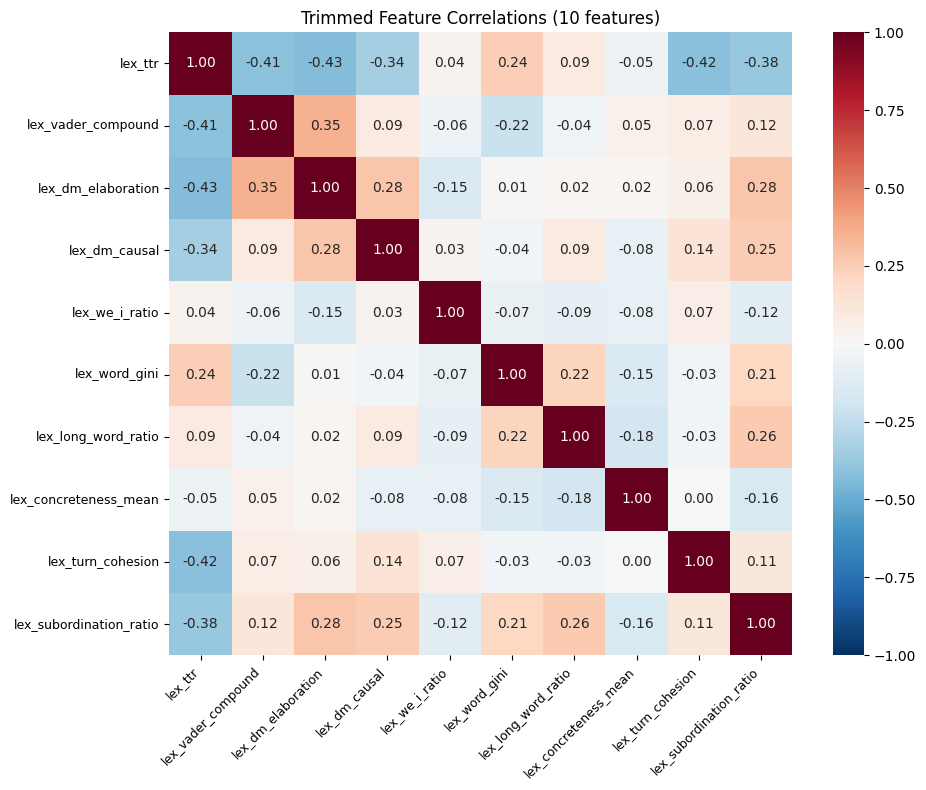


Max correlation in trimmed set: |r|=0.43 (ttr ↔ dm_elaboration)
✓ All correlations below 0.7 threshold


In [53]:
# Export trimmed feature set for regression models
trimmed_features = [
    "lex_ttr",                    # lexical diversity
    "lex_vader_compound",         # sentiment (VADER)  
    "lex_dm_elaboration",         # discourse - cognitive complexity
    "lex_dm_causal",              # discourse - reasoning
    "lex_we_i_ratio",             # pronoun - group focus
    "lex_word_gini",              # participation balance
    "lex_long_word_ratio",        # lexical sophistication
    "lex_concreteness_mean",      # psycholinguistic feature
    "lex_turn_cohesion",          # coherence between turns
    "lex_subordination_ratio",    # syntactic complexity (Tier 3)
]

# Check correlations within trimmed set
trimmed_corr = lex_df[trimmed_features].corr()
print(f"Correlation matrix for TRIMMED feature set ({len(trimmed_features)} features):")
print("-"*60)

# Display as heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(trimmed_corr, annot=True, fmt=".2f", cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title(f"Trimmed Feature Correlations ({len(trimmed_features)} features)")
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# Max correlation in trimmed set
max_corr = 0
for i, c1 in enumerate(trimmed_features):
    for j, c2 in enumerate(trimmed_features):
        if i < j:
            r = abs(trimmed_corr.loc[c1, c2])
            if r > max_corr:
                max_corr = r
                max_pair = (c1.replace("lex_", ""), c2.replace("lex_", ""))

print(f"\nMax correlation in trimmed set: |r|={max_corr:.2f} ({max_pair[0]} ↔ {max_pair[1]})")
print(f"✓ All correlations below 0.7 threshold" if max_corr < 0.7 else f"⚠ Some correlations still high")

### 4.6 Syntactic Complexity (spaCy dependency parsing)

**TIER 3 features** using spaCy:
- `parse_depth_mean`: Mean depth of dependency trees (deeper = more embedded clauses)
- `clause_density`: Clauses per sentence 
- `subordination_ratio`: Proportion of subordinate clauses

Reference: Lu, X. (2010). Automatic analysis of syntactic complexity in second language writing.

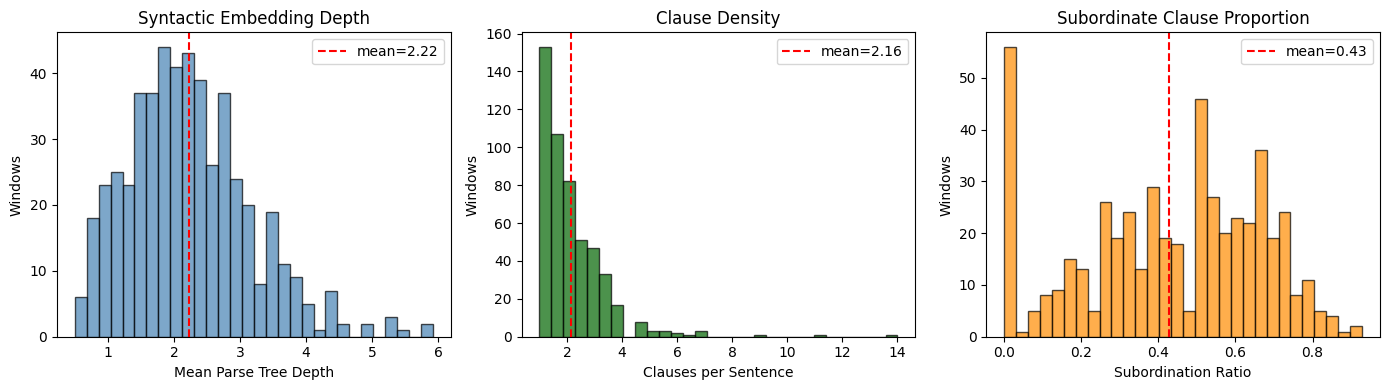

\nSyntactic Complexity Summary (TIER 3):
  - Parse depth mean: 2.22 (shallow = conversational)
  - Clause density: 2.16 clauses/sentence
  - Subordination: 42.9% of clauses are subordinate
  - Coverage: 513/682 windows parsed


In [50]:
# Reload data to get Tier 3 features
lex_df = pd.read_csv(lex_path, sep="\t")
feat_cols = [c for c in lex_df.columns if c.startswith("lex_")]

# Syntactic complexity QC
tier3_cols = ["lex_parse_depth_mean", "lex_clause_density", "lex_subordination_ratio"]

if all(c in lex_df.columns for c in tier3_cols):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    
    # Parse depth distribution
    ax = axes[0]
    data = lex_df["lex_parse_depth_mean"].dropna()
    ax.hist(data, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(data.mean(), color='red', linestyle='--', label=f"mean={data.mean():.2f}")
    ax.set_xlabel("Mean Parse Tree Depth")
    ax.set_ylabel("Windows")
    ax.set_title("Syntactic Embedding Depth")
    ax.legend()
    
    # Clause density distribution
    ax = axes[1]
    data = lex_df["lex_clause_density"].dropna()
    ax.hist(data, bins=30, edgecolor='black', alpha=0.7, color='darkgreen')
    ax.axvline(data.mean(), color='red', linestyle='--', label=f"mean={data.mean():.2f}")
    ax.set_xlabel("Clauses per Sentence")
    ax.set_ylabel("Windows")
    ax.set_title("Clause Density")
    ax.legend()
    
    # Subordination ratio distribution
    ax = axes[2]
    data = lex_df["lex_subordination_ratio"].dropna()
    ax.hist(data, bins=30, edgecolor='black', alpha=0.7, color='darkorange')
    ax.axvline(data.mean(), color='red', linestyle='--', label=f"mean={data.mean():.2f}")
    ax.set_xlabel("Subordination Ratio")
    ax.set_ylabel("Windows")
    ax.set_title("Subordinate Clause Proportion")
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Summary stats
    print("\\nSyntactic Complexity Summary (TIER 3):")
    print(f"  - Parse depth mean: {lex_df['lex_parse_depth_mean'].mean():.2f} (shallow = conversational)")
    print(f"  - Clause density: {lex_df['lex_clause_density'].mean():.2f} clauses/sentence")
    print(f"  - Subordination: {lex_df['lex_subordination_ratio'].mean():.1%} of clauses are subordinate")
    print(f"  - Coverage: {lex_df['lex_parse_depth_mean'].notna().sum()}/{len(lex_df)} windows parsed")
else:
    print("Tier 3 syntactic features not found — spaCy may not be installed")

In [ ]:
# Summary report
tier1_new = [
    "lex_dm_elaboration", "lex_dm_contrast", "lex_dm_causal", 
    "lex_dm_additive", "lex_dm_temporal",
    "lex_i_count", "lex_we_count", "lex_we_i_ratio",
    "lex_word_gini", "lex_word_hhi",
    "lex_long_word_ratio", "lex_turn_cohesion"
]
tier2_vader = ["lex_vader_compound", "lex_vader_pos", "lex_vader_neg", "lex_vader_neu"]
tier2_concreteness = ["lex_concreteness_mean", "lex_concreteness_std", "lex_concreteness_coverage"]
tier3_syntactic = ["lex_parse_depth_mean", "lex_clause_density", "lex_subordination_ratio"]

print("="*60)
print("LEXICAL FEATURES QC SUMMARY")
print("="*60)
print(f"Total windows extracted: {len(lex_df)}")
print(f"Groups: {lex_df['group_id'].nunique()}")
print(f"Tasks: {lex_df['task_id'].unique().tolist()}")
print(f"Total features: {len(feat_cols)}")
print(f"  - Original features: {len([c for c in feat_cols if c not in tier1_new and c not in tier2_vader and c not in tier2_concreteness and c not in tier3_syntactic])}")
print(f"  - Tier 1 NEW features: {len(tier1_new)}")
print(f"  - Tier 2 VADER features: {len(tier2_vader)}")
print(f"  - Tier 2 Concreteness features: {len(tier2_concreteness)}")
print(f"  - Tier 3 Syntactic features: {len(tier3_syntactic)}")
print(f"\nFeature categories:")
print(f"  - Discourse markers (Tier 1): 5")
print(f"  - Pronouns (Tier 1): 3 (i_count, we_count, we_i_ratio)")
print(f"  - Participation balance (Tier 1): 2 (word_gini, word_hhi)")
print(f"  - Lexical sophistication (Tier 1): 1 (long_word_ratio)")
print(f"  - Turn cohesion (Tier 1): 1 (turn_cohesion)")
print(f"  - VADER sentiment (Tier 2): 4 (compound, pos, neg, neu)")
print(f"  - Concreteness (Tier 2): 3 (mean, std, coverage)")
print(f"  - Syntactic complexity (Tier 3): 3 (parse_depth, clause_density, subordination)")
print(f"\nKey features:")
print(f"  - Concreteness mean: {lex_df['lex_concreteness_mean'].mean():.2f} (1=abstract, 5=concrete)")
print(f"  - Parse depth mean: {lex_df['lex_parse_depth_mean'].mean():.2f} (shallow = conversational)")
print(f"  - Subordination ratio: {lex_df['lex_subordination_ratio'].mean():.1%}")
print(f"\nSanity checks: {'All passed ✓' if all(p for _, p in checks) else 'Some failed ✗'}")
print("="*60)

LEXICAL FEATURES QC SUMMARY
Total windows extracted: 682
Groups: 10
Tasks: ['T1', 'T2', 'T3']
Total features: 37
  - Original features: 15
  - Tier 1 NEW features: 12
  - Tier 2 VADER features: 4
  - Tier 2 Concreteness features: 3
  - Tier 3 Syntactic features: 3

Feature categories:
  - Discourse markers (Tier 1): 5
  - Pronouns (Tier 1): 3 (i_count, we_count, we_i_ratio)
  - Participation balance (Tier 1): 2 (word_gini, word_hhi)
  - Lexical sophistication (Tier 1): 1 (long_word_ratio)
  - Turn cohesion (Tier 1): 1 (turn_cohesion)
  - VADER sentiment (Tier 2): 4 (compound, pos, neg, neu)
  - Concreteness (Tier 2): 3 (mean, std, coverage)
  - Syntactic complexity (Tier 3): 3 (parse_depth, clause_density, subordination)

Key features:
  - Concreteness mean: 2.41 (1=abstract, 5=concrete)
  - Parse depth mean: 2.22 (shallow = conversational)
  - Subordination ratio: 42.9%

Sanity checks: All passed ✓


: 